In [31]:
import pandas as pd
import geopandas as gpd

In [37]:
# /Users/cecile.becarie/LICIT_LAB Dropbox/Cecile Becarie/Projets/MnMS/Amsterdam/NewSimulations/Demand/test_all_in_highway_7h_9h.csv
# /Users/cecile.becarie/LICIT_LAB Dropbox/Cecile Becarie/Projets/MnMS/Amsterdam/NewSimulations/Demand/demand_from_Amsterdam.csv

demand_file_path = input("Demand file path: ")

Demand file path:  /Users/cecile.becarie/LICIT_LAB Dropbox/Cecile Becarie/Projets/MnMS/Amsterdam/NewSimulations/Demand/demand_from_Amsterdam.csv


In [38]:
df_demand = pd.read_csv(demand_file_path,sep=';')
df_demand['DEPARTURE'] = pd.to_datetime(df_demand['DEPARTURE'])

/var/folders/fq/lc9mrw2d2j70fr2tc9w3vl99tydj6l/T/ipykernel_28672/3683687906.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_demand['DEPARTURE'] = pd.to_datetime(df_demand['DEPARTURE'])


In [39]:
# Taille de la demande
print(len(df_demand))

65594


<Axes: xlabel='DEPARTURE_15min'>

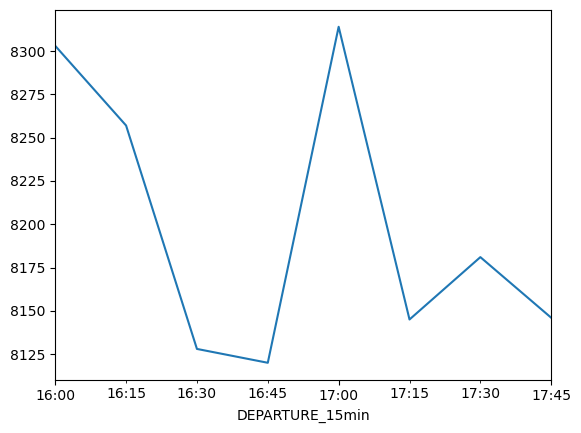

In [40]:
# Profil temporel de la demande
df_demand['DEPARTURE_15min'] = df_demand['DEPARTURE'].dt.floor('15min')
df_demand.groupby('DEPARTURE_15min').size().plot()

In [41]:
df_demand['ORIGIN_geom'] = gpd.points_from_xy(x=df_demand.ORIGIN.apply(lambda x: x.split(' ')[0]), y = df_demand.ORIGIN.apply(lambda x: x.split(' ')[1]))
df_demand['DESTINATION_geom'] = gpd.points_from_xy(x=df_demand.DESTINATION.apply(lambda x: x.split(' ')[0]), y = df_demand.DESTINATION.apply(lambda x: x.split(' ')[1]))

In [42]:
gdf_origin = gpd.GeoDataFrame(df_demand, geometry='ORIGIN_geom')
gdf_destination = gpd.GeoDataFrame(df_demand, geometry='DESTINATION_geom')

In [43]:
df_OD = df_demand.groupby(['ORIGIN', 'DESTINATION']).size()

In [44]:
df_OD

ORIGIN                               DESTINATION                         
618206.8426379832 5807813.882732262  622712.2683113535 5804559.8460797155    1
                                     629730.3182514048 5804672.090894435     1
                                     630212.5159632207 5803696.207096133     1
                                     635206.3507756804 5797264.126577879     1
618772.8192127077 5808503.210018341  629360.7353438672 5801563.780940913     1
                                                                            ..
637597.802830987 5802527.049334394   625495.5691442833 5804982.5380826       1
                                     634723.4089632495 5798241.242899219     1
637629.2149607344 5796771.610393161  623357.7701285477 5804721.42616213      1
                                     631139.4779811723 5803105.605516696     1
                                     634476.1344029797 5795434.605779178     1
Length: 55673, dtype: int64

In [45]:
df_inout_flow= pd.concat([df_demand.groupby('ORIGIN').size(), df_demand.groupby('DESTINATION').size()], axis=1, keys = ['Origin', 'Destination']).fillna(0).reset_index()
df_inout_flow['geometry'] = gpd.points_from_xy(x=df_inout_flow['index'].apply(lambda x: x.split(' ')[0]), y = df_inout_flow['index'].apply(lambda x: x.split(' ')[1]))
gdf_inout_flow = gpd.GeoDataFrame(df_inout_flow, geometry='geometry', crs= 'EPSG:32631')

In [46]:
gdf_inout_flow.crs

<Projected CRS: EPSG:32631>
Name: WGS 84 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
- bounds: (0.0, 0.0, 6.0, 84.0)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
gdf_inout_flow.explore()

In [12]:
df_inout_flow

,index,Origin,Destination,geometry
0,618206.8426379832 5807813.882732262,4.0,1.0,POINT (618206.843 5807813.883)
1,618772.8192127077 5808503.210018341,1.0,0.0,POINT (618772.819 5808503.21)
2,619131.9533648285 5807224.170893929,3.0,2.0,POINT (619131.953 5807224.171)
3,619296.2265274503 5808360.539122885,2.0,0.0,POINT (619296.227 5808360.539)
4,619722.7602578653 5802167.623113418,3.0,0.0,POINT (619722.76 5802167.623)
...,...,...,...,...
899,632762.7678510598 5807897.946745409,0.0,1.0,POINT (632762.768 5807897.947)
900,633693.7438752805 5809501.257898281,0.0,2.0,POINT (633693.744 5809501.258)
901,634453.6183731679 5805580.011402294,0.0,1.0,POINT (634453.618 5805580.011)
902,634776.6753517532 5805660.859990221,0.0,3.0,POINT (634776.675 5805660.86)


<Axes: >

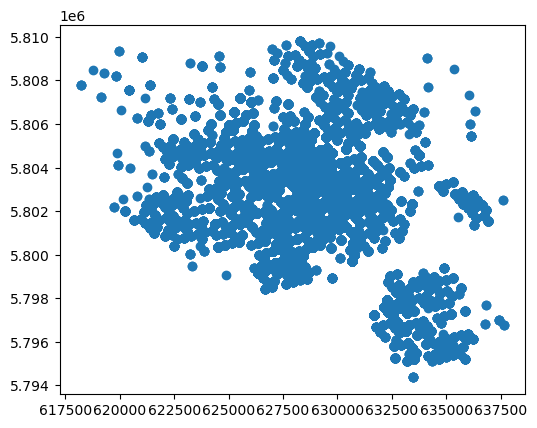

In [13]:
gdf_origin.plot()

In [14]:
file_path = input("Entrez le chemin du fichier : ")

Entrez le chemin du fichier :  '/Users/cecile.becarie/LICIT_LAB Dropbox/Cecile Becarie/Projets/MnMS/Amsterdam/NewSimulations/Demand/demand.csv'


In [15]:
file_path



"'/Users/cecile.becarie/LICIT_LAB Dropbox/Cecile Becarie/Projets/MnMS/Amsterdam/NewSimulations/Demand/demand.csv'"